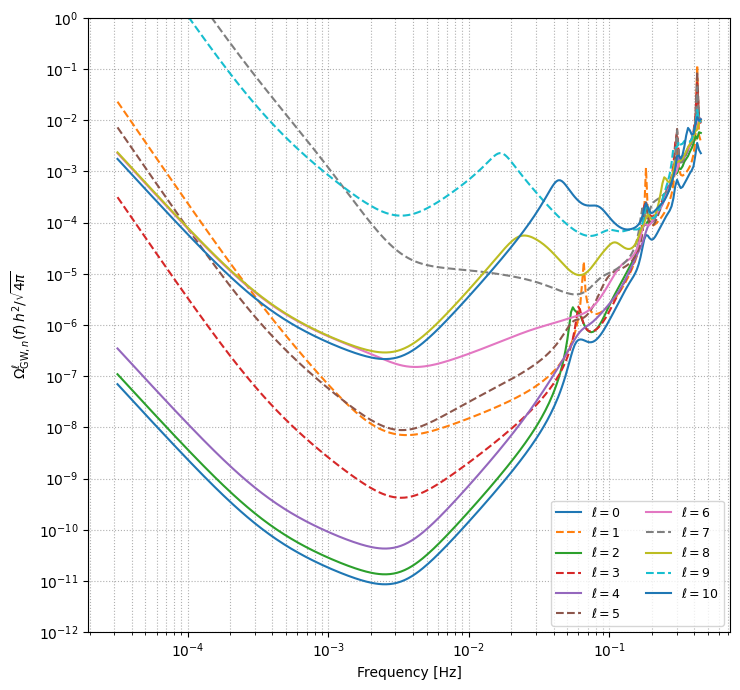

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from matplotlib.ticker import LogLocator, LogFormatterMathtext
from scipy.special import sph_harm
from schnell.mapping import MapCalculator
from schnell.detector import LISADetector


# ============================================================
# Constants (paper)
# ============================================================
C_LIGHT = 299_792_458.0
L_ARM   = 2.5e9
F_STAR  = C_LIGHT / (2.0*np.pi*L_ARM)

MPC_M     = 3.0856775814913673e22
H0_OVER_h = (100.0 * 1000.0) / MPC_M

P_OMS_PM = 15.0
A_ACC_FM = 3.0

# Paper plotting rescaling
Y00 = 1.0 / np.sqrt(8.0*np.pi)

# ============================================================
# Appendix B: Noise functions
# ============================================================
def S_oms(f):
    f = np.asarray(f, float)
    return (P_OMS_PM * 1e-12)**2 * (1.0 + (2.0e-3 / f)**4)

def S_acc(f):
    f = np.asarray(f, float)
    return (A_ACC_FM * 1e-15)**2 * (1.0 + (0.4e-3 / f)**2) * (1.0 + (f / 8.0e-3)**4)

def N_tilde_AE(f):
    f = np.asarray(f, float)
    x = f / F_STAR
    cosx = np.cos(x)
    term_oms = 0.5 * (2.0 + cosx) * (S_oms(f) / L_ARM**2)
    term_acc = 2.0 * (1.0 + cosx + cosx**2) * (S_acc(f) / L_ARM**2) * (1.0/(2.0*np.pi*f))**4
    return term_oms + term_acc

def N_tilde_T(f):
    f = np.asarray(f, float)
    x = f / F_STAR
    one_minus_cos = 1.0 - np.cos(x)
    term_oms = one_minus_cos * (S_oms(f) / L_ARM**2)
    term_acc = 2.0 * (one_minus_cos**2) * (S_acc(f) / L_ARM**2) * (1.0/(2.0*np.pi*f))**4
    return term_oms + term_acc

# ============================================================
# Appendix A helpers (same math as before)
# ============================================================
def sinc(x):
    x = np.asarray(x)
    out = np.ones_like(x, dtype=np.complex128)
    small = np.abs(x) < 1e-12
    xs = x[~small]
    out[~small] = np.sin(xs) / xs
    return out

def M_transfer(u, mu):
    arg = 0.5 * u * (1.0 + mu)
    return np.exp(1j * arg) * sinc(arg)

def T_transfer(u, mu):
    return np.exp(-1j*u) * M_transfer(u, -mu) + np.exp(-1j*u*mu) * M_transfer(u, mu)

# ============================================================
# Polarization tensors and projections on a HEALPix grid
# ============================================================
def healpix_grid(nside):
    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix), nest=False)
    sin_t = np.sin(theta)
    khat = np.stack([sin_t*np.cos(phi), sin_t*np.sin(phi), np.cos(theta)], axis=1)
    return khat, theta, phi

def polarization_tensors_from_k(khat, theta, phi):
    e_theta = np.stack([np.cos(theta)*np.cos(phi),
                        np.cos(theta)*np.sin(phi),
                        -np.sin(theta)], axis=1)
    e_phi = np.stack([-np.sin(phi),
                      np.cos(phi),
                      np.zeros_like(phi)], axis=1)
    e_plus  = e_theta[:, :, None]*e_theta[:, None, :] - e_phi[:, :, None]*e_phi[:, None, :]
    e_cross = e_theta[:, :, None]*e_phi[:, None, :]   + e_phi[:, :, None]*e_theta[:, None, :]
    return e_plus, e_cross

def g_pol_from_arm(lhat, e_tensor):
    return 0.5 * np.einsum("i,j,nij->n", lhat, lhat, e_tensor)

# ============================================================
# A,E,T channel mixing (paper Eq. 4.25)
# ============================================================
C_AET = np.array([
    [-1/np.sqrt(2),  0.0,           1/np.sqrt(2)],  # A
    [ 1/np.sqrt(6), -2/np.sqrt(6),  1/np.sqrt(6)],  # E
    [ 1/np.sqrt(3),  1/np.sqrt(3),  1/np.sqrt(3)],  # T
], dtype=float)
O_list = ["A", "E", "T"]
O_idx  = {O: i for i, O in enumerate(O_list)}

# ============================================================
# Sensitivity equations (paper Eqs. 4.42-4.43)
# ============================================================
def omega_channel_channel(f, Rtilde, Ntilde_O, Ntilde_Op):
    pref = (4.0*np.pi**2 * np.sqrt(4.0*np.pi)) / (3.0 * (H0_OVER_h**2))
    return pref * (f**3) * (np.sqrt(Ntilde_O * Ntilde_Op) / Rtilde)

def optimal_omega_from_ordered_pairs(omega_pairs_9):
    inv2 = np.zeros_like(omega_pairs_9[0], dtype=float)
    for om in omega_pairs_9:
        inv2 += 1.0 / (om*om)
    return 1.0 / np.sqrt(inv2)

# ============================================================
# Key point for "real basis" + iter=1 with complex sky maps
# ============================================================
# healpy.map2alm(...) assumes a *real* map (standard use case).
# Our per-frequency sky maps are complex because of exp(-2π i f k·Δx).
#
# To use healpy's SHT machinery (and thus iter=1) while keeping the *full*
# complex harmonic content, we compute:
#   a_{lm}^*basis  = ∫ f(Ω) Y_{lm}^*(Ω) dΩ  via map2alm(Re f) + i map2alm(Im f)
# and also
#   b_{lm}         = ∫ f(Ω) Y_{lm}(Ω)  dΩ  via map2alm(Re f) - i map2alm(Im f) but with
# the correct operation: b_{lm} = (∫ f*(Ω) Y_{lm}^*(Ω) dΩ)^*.
#
# For any complex f:
#   c_{lm} := ∫ f*(Ω) Y_{lm}^*(Ω) dΩ
# then
#   b_{lm} = c_{lm}^*.
#
# So we compute:
#   alm_f  = map2alm(Re f) + i map2alm(Im f)         (m>=0 stored)
#   alm_fc = map2alm(Re f) - i map2alm(Im f)         equals map2alm(conj(f)) (linearity)
# and use:
#   power_l = |a_{l0}|^2 + sum_{m=1..l} ( |a_{lm}|^2 + |c_{lm}|^2 )
# where c_{lm} are the coefficients from alm_fc (since alm_fc = c_{lm} for m>=0).
#
# This quantity equals sum_{m=-l..l} |Z_{lm}|^2 for the complex-harmonic basis,
# i.e. the rotation-invariant response used in the paper.
#
# ============================================================

def precompute_alm_indices(lmax):
    idx_by_ell = {}
    idx_mpos_by_ell = {}
    for ell in range(lmax + 1):
        idxs = [hp.Alm.getidx(lmax, ell, m) for m in range(0, ell + 1)]
        idx_by_ell[ell] = np.array(idxs, dtype=np.int64)
        if ell >= 1:
            idxs_mpos = [hp.Alm.getidx(lmax, ell, m) for m in range(1, ell + 1)]
            idx_mpos_by_ell[ell] = np.array(idxs_mpos, dtype=np.int64)
        else:
            idx_mpos_by_ell[ell] = np.array([], dtype=np.int64)
    return idx_by_ell, idx_mpos_by_ell

def reproduce_figure9_healpy_real_basis_iter1(f_grid, lmax=10, nside=32, iter_sht=1):
    """
    Uses healpy's spherical harmonic transform with iter=iter_sht (e.g. 1),
    while correctly accounting for complex sky maps by computing both:
      a_lm = ∫ f Y_lm^* dΩ
      c_lm = ∫ f* Y_lm^* dΩ
    and forming:
      sum_{m=-l..l} |Z_lm|^2  ==  |a_l0|^2 + Σ_{m=1..l} (|a_lm|^2 + |c_lm|^2)

    This is equivalent to working in a real spherical-harmonic basis (cos/sin modes),
    and it allows use of iter=1 without losing the negative-m information.
    """
    f_grid = np.asarray(f_grid, float)
    if lmax > 3*nside - 1:
        raise ValueError(f"HEALPix sampling constraint: need lmax <= 3*nside-1, got lmax={lmax}, nside={nside}")

    # --- Geometry (same as before)
    L = L_ARM
    r1 = np.array([0.0, 0.0, 0.0])
    r2 = np.array([L,   0.0, 0.0])
    r3 = np.array([0.5*L, 0.5*np.sqrt(3.0)*L, 0.0])
    pos = [r1, r2, r3]

    def unit(v):
        return v / np.linalg.norm(v)

    l12 = unit(r2-r1); l13 = unit(r3-r1)
    l21 = unit(r1-r2); l23 = unit(r3-r2)
    l31 = unit(r1-r3); l32 = unit(r2-r3)

    arms_by_sc = {0: (l12, l13), 1: (l23, l21), 2: (l31, l32)}

    pos_sec = [p / C_LIGHT for p in pos]
    delta_sec = np.zeros((3, 3, 3))
    for i in range(3):
        for j in range(3):
            delta_sec[i, j] = pos_sec[i] - pos_sec[j]

    # --- HEALPix sky (ring)
    khat, theta, phi = healpix_grid(nside)
    npix = khat.shape[0]

    # Polarization tensors on sky
    e_plus, e_cross = polarization_tensors_from_k(khat, theta, phi)

    # --- Precompute arm-dependent sky projections (geometry-only)
    mu_a  = np.empty((3, npix), dtype=np.float64)
    mu_b  = np.empty((3, npix), dtype=np.float64)
    gp_a  = np.empty((3, npix), dtype=np.float64)
    gx_a  = np.empty((3, npix), dtype=np.float64)
    gp_b  = np.empty((3, npix), dtype=np.float64)
    gx_b  = np.empty((3, npix), dtype=np.float64)

    for i in range(3):
        la, lb = arms_by_sc[i]
        mu_a[i] = khat @ la
        mu_b[i] = khat @ lb
        gp_a[i] = g_pol_from_arm(la, e_plus).real
        gx_a[i] = g_pol_from_arm(la, e_cross).real
        gp_b[i] = g_pol_from_arm(lb, e_plus).real
        gx_b[i] = g_pol_from_arm(lb, e_cross).real

    # --- Precompute k·Δx_ij on pixels
    kdot_delta = np.zeros((3, 3, npix), dtype=np.float64)
    for i in range(3):
        for j in range(3):
            kdot_delta[i, j] = khat @ delta_sec[i, j]
    kdot_flat = kdot_delta.reshape(9, npix)

    # --- Precompute mixing from ij-flat(9) to ordered channel pairs(9)
    pairs = [(O, Op) for O in O_list for Op in O_list]  # 9 ordered
    Mix = np.empty((9, 9), dtype=np.float64)
    for pidx, (O, Op) in enumerate(pairs):
        cO  = C_AET[O_idx[O]]
        cOp = C_AET[O_idx[Op]]
        Mix[pidx, :] = (cO[:, None] * cOp[None, :]).reshape(9)

    # --- Noise arrays
    N_A = N_tilde_AE(f_grid)
    N_E = N_A.copy()
    N_T = N_tilde_T(f_grid)
    N_map = {"A": N_A, "E": N_E, "T": N_T}

    # --- ALM index helpers
    idx_by_ell, idx_mpos_by_ell = precompute_alm_indices(lmax)

    # Output
    omega_by_ell = {ell: np.zeros_like(f_grid) for ell in range(lmax + 1)}

    # Work arrays
    Rplus  = np.empty((3, npix), dtype=np.complex128)
    Rcross = np.empty((3, npix), dtype=np.complex128)

    # Normalization prefactor for Eq. (4.15): 1/(8π)
    pref_Rlm = 1.0 / (8.0 * np.pi)

    # Main frequency loop
    for fi, f in enumerate(f_grid):
        u = f / F_STAR

        # Transfer functions for each arm (vectorized)
        Ta_a = T_transfer(u, mu_a)  # (3,npix) complex
        Ta_b = T_transfer(u, mu_b)  # (3,npix) complex

        # R_i^+, R_i^x
        Rplus[:]  = gp_a * Ta_a - gp_b * Ta_b
        Rcross[:] = gx_a * Ta_a - gx_b * Ta_b

        # Σ_A R_i^A R_j^{A*}
        pol_sum = (Rplus[:, None, :] * np.conj(Rplus[None, :, :]) +
                   Rcross[:, None, :] * np.conj(Rcross[None, :, :]))  # (3,3,npix)

        # phase for all ij at once
        phase_flat = np.exp(-2j * np.pi * f * kdot_flat)  # (9,npix)

        # Eq. (4.15) sky "maps" for each ij (flattened): f_ij(Ω) = (1/8π) pol_sum * phase
        maps_ij_flat = pref_Rlm * pol_sum.reshape(9, npix) * phase_flat  # (9,npix) complex

        # Mix ij maps into 9 ordered channel-pair maps (still on sky pixels)
        # maps_pair[pair, pix] = Σ_ij Mix[pair,ij] * maps_ij[ij,pix]
        maps_pair = Mix @ maps_ij_flat  # (9,npix) complex

        # For each channel-pair map, compute two ALM sets:
        #  alm_a : a_lm = ∫ f Y_lm^* dΩ (m>=0 stored)
        #  alm_c : c_lm = ∫ f* Y_lm^* dΩ (m>=0 stored), which we get via map2alm(conj(f))
        #
        # Since healpy expects real map input, we do:
        #  map2alm(Re f) and map2alm(Im f) separately, then combine.
        #
        # For conj(f): Re same, Im negated.
        alms_a = []
        alms_c = []
        for pidx in range(9):
            mp = maps_pair[pidx]
            mp_re = mp.real.astype(np.float64, copy=False)
            mp_im = mp.imag.astype(np.float64, copy=False)

            # a_lm = A + i B
            A = hp.map2alm(mp_re, lmax=lmax, iter=iter_sht, pol=False)
            B = hp.map2alm(mp_im, lmax=lmax, iter=iter_sht, pol=False)
            alm_a = A + 1j * B

            # c_lm = map2alm(conj(f)) = map2alm(Re f - i Im f) = A - i B
            alm_c = A - 1j * B

            alms_a.append(alm_a)
            alms_c.append(alm_c)

        # Now compute Rtilde^ell for each pair using full m power:
        # power_ell = |a_l0|^2 + Σ_{m=1..ell} ( |a_lm|^2 + |c_lm|^2 )
        for ell in range(lmax + 1):
            idx0 = hp.Alm.getidx(lmax, ell, 0)
            idxm = idx_mpos_by_ell[ell]

            Rtilde_pairs = np.empty(9, dtype=np.float64)
            for pidx in range(9):
                aa = alms_a[pidx]
                cc = alms_c[pidx]

                power = np.abs(aa[idx0])**2
                if idxm.size > 0:
                    power += np.sum(np.abs(aa[idxm])**2) + np.sum(np.abs(cc[idxm])**2)

                Rtilde_pairs[pidx] = np.sqrt(power)
            Rtilde_pairs = np.maximum(Rtilde_pairs, 1e-45)

            # Build 9 Omegas for ordered pairs and optimally combine
            omega_pairs = []
            for pidx, (O, Op) in enumerate(pairs):
                omega_pairs.append(
                    omega_channel_channel(f, Rtilde_pairs[pidx], N_map[O][fi], N_map[Op][fi])
                )

            omega_by_ell[ell][fi] = optimal_omega_from_ordered_pairs(omega_pairs) * Y00

    return omega_by_ell

# ============================================================
# Example run + plot
# ============================================================
if __name__ == "__main__":
    f = np.logspace(-4.5, -0.35, 320)

    # More accuracy via iter=1 on the SHT side; true integral accuracy still improves with nside
    curves = reproduce_figure9_healpy_real_basis_iter1(
        f_grid=f,
        lmax=10,
        nside=128,      # increase for better angular accuracy
        iter_sht=0    # your request
    )

    plt.figure(figsize=(7.5, 7))
    for ell in range(0, 11):
        ls = "-" if (ell % 2 == 0) else "--"
        plt.loglog(f, curves[ell], linestyle=ls, label=rf"$\ell={ell}$")
    
    plt.xlabel("Frequency [Hz]")
    plt.ylabel(r"$\Omega^{\ell}_{{\rm GW},n}(f)\,h^2 / \sqrt{4\pi}$")
    plt.ylim(1e-12, 1e0)
    
    ax = plt.gca()
    
    # Show every power of 10 on the y-axis
    ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1.0,), numticks=100))
    ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
    
    plt.grid(True, which="both", linestyle=":")
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

min Omega_plus: 7.371232760775983e-27
min Omega_minus: 4.0951891978337856e-10
any Omega_plus < 0? False
any Omega_minus < 0? False
max |Omega_V| / Omega_I: 1.0
any |Omega_V| > Omega_I? False
gamma_plus min/max: 0.01576575 38.75579953371411
gamma_minus min/max: 0.0 0.19962499403914194


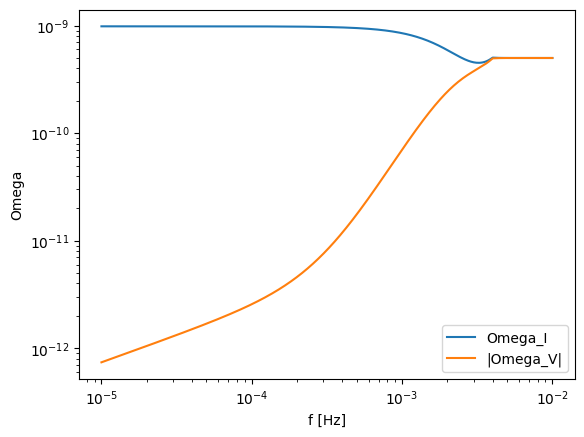

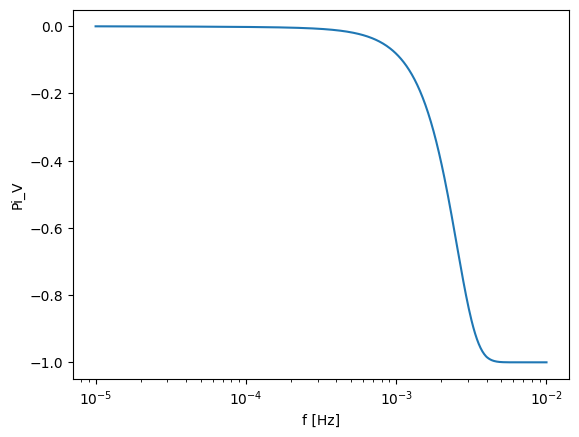

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def cvtd_spectrum(fs, fref=1e-3, Z_eff=1.5,
                  gamma=0.0, log_omega0=-9.0,
                  log_alpha=-2.0, beta=0.005, log_fstar=-3.5):
    omega0 = 10**log_omega0
    alpha = 10**log_alpha
    fstar = 10**log_fstar

    omega_prim = omega0 * (fs / fref)**gamma

    coeff = np.sqrt(fs / fref)
    gamma_plus = (1.0 + (fs / fstar)**2) * (alpha + beta * coeff) * Z_eff
    gamma_minus = (1.0 + (fs / fstar)**2) * (alpha - beta * coeff) * Z_eff

    gamma_plus = np.maximum(gamma_plus, 0.0)
    gamma_minus = np.maximum(gamma_minus, 0.0)

    x_plus = np.clip(-gamma_plus, -700, 700)
    x_minus = np.clip(-gamma_minus, -700, 700)

    omega_plus = 0.5 * omega_prim * np.exp(x_plus)
    omega_minus = 0.5 * omega_prim * np.exp(x_minus)

    omega_I = omega_plus + omega_minus
    omega_V = omega_plus - omega_minus

    Pi_V = np.full_like(omega_I, np.nan)
    mask = np.isfinite(omega_I) & (omega_I > 0)
    Pi_V[mask] = omega_V[mask] / omega_I[mask]

    print("min Omega_plus:", np.min(omega_plus))
    print("min Omega_minus:", np.min(omega_minus))
    print("any Omega_plus < 0?", np.any(omega_plus < 0))
    print("any Omega_minus < 0?", np.any(omega_minus < 0))
    
    print("max |Omega_V| / Omega_I:", np.nanmax(np.abs(omega_V) / omega_I))
    print("any |Omega_V| > Omega_I?", np.any(np.abs(omega_V) > omega_I * (1 + 1e-10)))

    return omega_I, omega_V, Pi_V, gamma_plus, gamma_minus

fs = np.logspace(-5, -2, 500)
omega_I, omega_V, Pi_V, gp, gm = cvtd_spectrum(fs)

print("gamma_plus min/max:", np.min(gp), np.max(gp))
print("gamma_minus min/max:", np.min(gm), np.max(gm))

plt.loglog(fs, omega_I, label="Omega_I")
plt.loglog(fs, np.abs(omega_V), label="|Omega_V|")
plt.legend()
plt.xlabel("f [Hz]")
plt.ylabel("Omega")
plt.show()

plt.semilogx(fs, Pi_V)
plt.xlabel("f [Hz]")
plt.ylabel("Pi_V")
plt.show()

In [5]:
# ------------------------------------------
# Observation time
# ------------------------------------------
T_obs = 3.0 * 365.25 * 24.0 * 3600.0   # 3 years

# ------------------------------------------
# Example signal model used in Eq. (4.44)
# Omega_sig^ell(f) h^2 = A_ell * (f/fc)^alpha
# Set these however you want
# ------------------------------------------
fc = 2.5e-3
alpha = 0.0
A_ell = 1.0

# ------------------------------------------
# Compute I_ell, SNR^2, SNR
# ------------------------------------------
rows = []
for ell in range(11):
    Omega_sig_ell = A_ell * (f / fc)**alpha
    integrand = (Omega_sig_ell / curves[ell])**2
    I_ell = np.trapz(integrand, f)
    snr2 = T_obs * I_ell
    snr = np.sqrt(snr2)
    rows.append((ell, I_ell, snr2, snr))

# ------------------------------------------
# Nicely formatted table
# ------------------------------------------
print()
print("=" * 68)
print(f"{'ell':>5}  {'Integral I_ell':>18}  {'SNR^2':>18}  {'SNR':>18}")
print("=" * 68)
for ell, I_ell, snr2, snr in rows:
    print(f"{ell:5d}  {I_ell:18.8e}  {snr2:18.8e}  {snr:18.8e}")
print("=" * 68)
print()


  ell      Integral I_ell               SNR^2                 SNR
    0      3.71127903e+19      3.51357178e+27      5.92753893e+13
    1      1.24143887e+14      1.17530494e+22      1.08411482e+11
    2      1.51236840e+19      1.43180151e+27      3.78391532e+13
    3      2.01310235e+16      1.90586036e+24      1.38052901e+12
    4      1.48799655e+18      1.40872800e+26      1.18689848e+13
    5      5.27664619e+13      4.99554869e+21      7.06791956e+10
    6      3.50239592e+11      3.31581628e+19      5.75831250e+09
    7      3.01896646e+09      2.85814008e+17      5.34615758e+08
    8      3.29497541e+10      3.11944548e+18      1.76619520e+09
    9      3.07138593e+07      2.90776706e+15      5.39237151e+07
   10      5.88624491e+10      5.57267288e+18      2.36065094e+09



In [6]:
T_obs = 3.0 * 365.25 * 24.0 * 3600.0   # 3 years

rows = []
for ell in range(11):
    I_ell = np.trapz(1.0 / curves[ell]**2, f)
    snr2 = T_obs * I_ell
    snr = np.sqrt(snr2)
    rows.append((ell, I_ell, snr2, snr))

print()
print("=" * 68)
print(f"{'ell':>5}  {'Integral I_ell':>18}  {'SNR^2':>18}  {'SNR':>18}")
print("=" * 68)
for ell, I_ell, snr2, snr in rows:
    print(f"{ell:5d}  {I_ell:18.8e}  {snr2:18.8e}  {snr:18.8e}")
print("=" * 68)
print()


  ell      Integral I_ell               SNR^2                 SNR
    0      3.71127903e+19      3.51357178e+27      5.92753893e+13
    1      1.24143887e+14      1.17530494e+22      1.08411482e+11
    2      1.51236840e+19      1.43180151e+27      3.78391532e+13
    3      2.01310235e+16      1.90586036e+24      1.38052901e+12
    4      1.48799655e+18      1.40872800e+26      1.18689848e+13
    5      5.27664619e+13      4.99554869e+21      7.06791956e+10
    6      3.50239592e+11      3.31581628e+19      5.75831250e+09
    7      3.01896646e+09      2.85814008e+17      5.34615758e+08
    8      3.29497541e+10      3.11944548e+18      1.76619520e+09
    9      3.07138593e+07      2.90776706e+15      5.39237151e+07
   10      5.88624491e+10      5.57267288e+18      2.36065094e+09



In [7]:
from scipy.integrate import simpson

T_obs = 3.0 * 365.25 * 24.0 * 3600.0   # 3 years
lnf = np.log(f)

rows = []
for ell in range(11):
    Omega_sig_ell = 1.0   # or A_ell * (f/fc)**alpha
    integrand_log = f * (Omega_sig_ell / curves[ell])**2
    I_ell = simpson(integrand_log, x=lnf)
    snr2 = T_obs * I_ell
    snr = np.sqrt(snr2)
    rows.append((ell, I_ell, snr2, snr))

print(f"{'ell':>3} {'I_ell':>16} {'SNR^2':>16} {'SNR':>16}")
for ell, I_ell, snr2, snr in rows:
    print(f"{ell:3d} {I_ell:16.6e} {snr2:16.6e} {snr:16.6e}")

ell            I_ell            SNR^2              SNR
  0     3.710724e+19     3.513046e+27     5.927096e+13
  1     1.241253e+14     1.175129e+22     1.084034e+11
  2     1.512142e+19     1.431587e+27     3.783632e+13
  3     2.012801e+16     1.905575e+24     1.380426e+12
  4     1.487774e+18     1.408517e+26     1.186810e+13
  5     5.275857e+13     4.994802e+21     7.067391e+10
  6     3.501872e+11     3.315320e+19     5.757882e+09
  7     3.018515e+09     2.857713e+17     5.345758e+08
  8     3.294483e+10     3.118979e+18     1.766063e+09
  9     3.070923e+07     2.907329e+15     5.391965e+07
 10     5.885365e+10     5.571840e+18     2.360474e+09


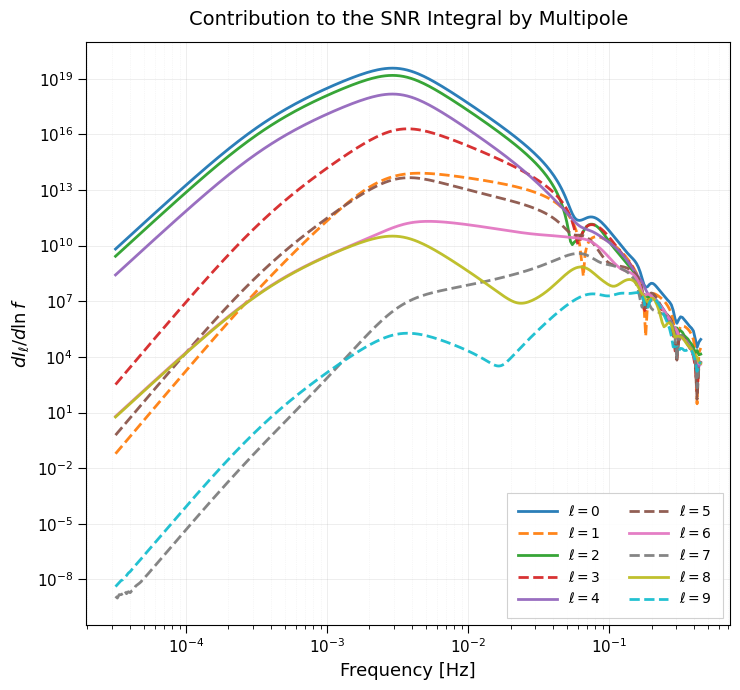

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext

fig, ax = plt.subplots(figsize=(7.5, 7.0))

for ell in range(10):
    dIdlnf = f * (Omega_sig_ell / curves[ell])**2
    ls = "-" if ell % 2 == 0 else "--"
    ax.loglog(
        f,
        dIdlnf,
        linestyle=ls,
        linewidth=2.0,
        alpha=0.95,
        label=rf"$\ell={ell}$"
    )

ax.set_xlabel("Frequency [Hz]", fontsize=13)
ax.set_ylabel(r"$dI_\ell / d\ln f$", fontsize=13)
ax.set_title(r"Contribution to the SNR Integral by Multipole", fontsize=14, pad=12)

ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1.0,), numticks=12))
ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1.0,), numticks=12))
ax.xaxis.set_major_formatter(LogFormatterMathtext(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))

ax.grid(True, which="major", linestyle="-", linewidth=0.6, alpha=0.25)
ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.2)

ax.tick_params(axis="both", which="major", labelsize=11, length=6)
ax.tick_params(axis="both", which="minor", length=3)

leg = ax.legend(
    ncol=2,
    fontsize=10,
    frameon=True,
    fancybox=False,
    framealpha=0.9,
    borderpad=0.8,
    handlelength=2.8,
    loc="best"
)
leg.get_frame().set_linewidth(0.8)

plt.tight_layout()
plt.show()

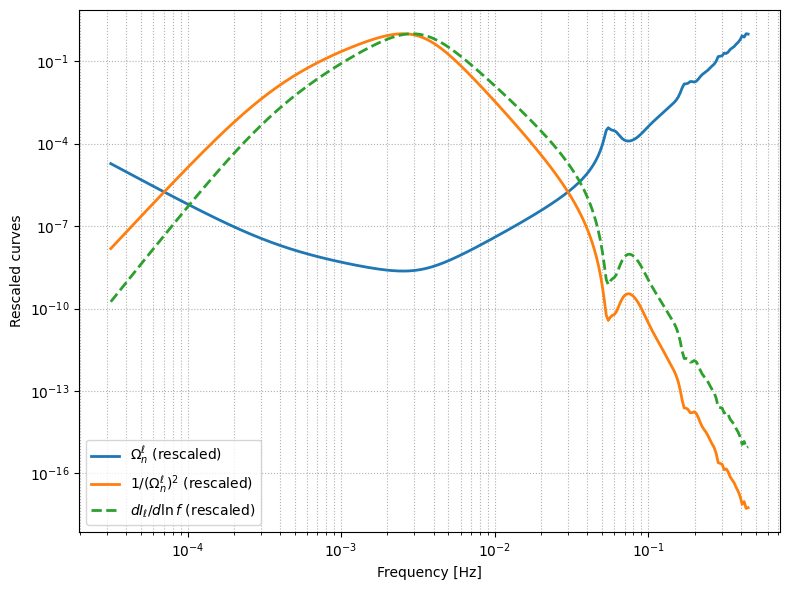

In [12]:
import numpy as np
import matplotlib.pyplot as plt

ell = 2

sens = curves[ell]
inv2 = 1.0 / sens**2
dIdlnf = f * (Omega_sig_ell / sens)**2

fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(f, sens / np.max(sens), label=r"$\Omega_n^\ell$ (rescaled)", linewidth=2)
ax.loglog(f, inv2 / np.max(inv2), label=r"$1/(\Omega_n^\ell)^2$ (rescaled)", linewidth=2)
ax.loglog(f, dIdlnf / np.max(dIdlnf), label=r"$dI_\ell/d\ln f$ (rescaled)", linewidth=2, linestyle="--")

ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Rescaled curves")
ax.legend()
ax.grid(True, which="both", ls=":")
plt.tight_layout()
plt.show()

In [13]:
import numpy as np

# ----------------------------
# Helper: convert (strain-like) PSD N_ij to Omega-units
# N^Omega_ij(f) = (4 pi^2 f^3)/(3 (H0/h)^2) * N_ij(f)
# ----------------------------
def omega_prefactor(f):
    f = np.asarray(f, float)
    return 4.0 * np.pi**2 * f**3 / (3.0 * (H0_OVER_h**2))

# ----------------------------
# Noise model with explicit parameters (P_oms in pm, A_acc in fm/s^2)
# Follows the same functional forms you already coded.
# These are the *tilde-noises* (Appendix B of the anisotropy paper).
# ----------------------------
def S_oms_param(f, P_oms_pm):
    f = np.asarray(f, float)
    return (P_oms_pm * 1e-12)**2 * (1.0 + (2.0e-3 / f)**4)

def S_acc_param(f, A_acc_fm):
    f = np.asarray(f, float)
    return (A_acc_fm * 1e-15)**2 * (1.0 + (0.4e-3 / f)**2) * (1.0 + (f / 8.0e-3)**4)

def N_tilde_AE_param(f, P_oms_pm, A_acc_fm):
    f = np.asarray(f, float)
    x = f / F_STAR
    cosx = np.cos(x)
    term_oms = 0.5 * (2.0 + cosx) * (S_oms_param(f, P_oms_pm) / L_ARM**2)
    term_acc = 2.0 * (1.0 + cosx + cosx**2) * (S_acc_param(f, A_acc_fm) / L_ARM**2) * (1.0/(2.0*np.pi*f))**4
    return term_oms + term_acc

def N_tilde_T_param(f, P_oms_pm, A_acc_fm):
    f = np.asarray(f, float)
    x = f / F_STAR
    one_minus_cos = 1.0 - np.cos(x)
    term_oms = one_minus_cos * (S_oms_param(f, P_oms_pm) / L_ARM**2)
    term_acc = 2.0 * (one_minus_cos**2) * (S_acc_param(f, A_acc_fm) / L_ARM**2) * (1.0/(2.0*np.pi*f))**4
    return term_oms + term_acc

# ----------------------------
# Restore the "full" common factor:
# R_ij(f) = 16 sin^2(x) x^2 * Rtilde_ij(f),  with x = 2 pi f L / c = f/F_STAR
# N_ij(f) = 16 sin^2(x) x^2 * Ntilde_ij(f)
# ----------------------------
def full_prefactor_16sin2x_x2(f):
    f = np.asarray(f, float)
    x = 2.0*np.pi*f*L_ARM/C_LIGHT
    return 16.0 * (np.sin(x)**2) * (x**2)

# ----------------------------
# Fast analytic fits for the *geometrical* factors Rtilde_AA and Rtilde_TT
# (Eqs. 2.24-2.25 in the sampling paper)
# ----------------------------
def Rtilde_AA_fit(f):
    f = np.asarray(f, float)
    x = 2.0*np.pi*f*L_ARM/C_LIGHT
    return (9.0/20.0) / (1.0 + 0.7*x*x)

def Rtilde_TT_fit(f):
    f = np.asarray(f, float)
    x = 2.0*np.pi*f*L_ARM/C_LIGHT
    return (9.0/20.0) * (x**6) / (1.8e3 + 0.7*(x**8))

def R_full_channel(f, channel, response_mode="fit", Rtilde_cache=None):
    """
    Returns the full response R_ii(f) for channel in {A,E,T}.
    response_mode:
      - "fit": use analytic fits (recommended for MCMC)
      - "cache": use precomputed Rtilde_cache[channel] on the same f grid
    """
    f = np.asarray(f, float)

    if response_mode == "fit":
        if channel in ("A", "E"):
            Rtilde = Rtilde_AA_fit(f)
        elif channel == "T":
            Rtilde = Rtilde_TT_fit(f)
        else:
            raise ValueError("channel must be 'A','E', or 'T'")
    elif response_mode == "cache":
        if Rtilde_cache is None or channel not in Rtilde_cache:
            raise ValueError("Need Rtilde_cache dict with keys 'A','E','T'")
        Rtilde = np.asarray(Rtilde_cache[channel], float)
        if Rtilde.shape != f.shape:
            raise ValueError("Rtilde_cache arrays must match shape of f")
    else:
        raise ValueError("response_mode must be 'fit' or 'cache'")

    return full_prefactor_16sin2x_x2(f) * Rtilde

def N_full_channel(f, channel, P_oms_pm, A_acc_fm):
    """
    Returns the full noise PSD N_ii(f) for channel in {A,E,T},
    built from the Appendix-B tilde noises by restoring the common factor.
    """
    f = np.asarray(f, float)
    if channel in ("A","E"):
        Ntilde = N_tilde_AE_param(f, P_oms_pm, A_acc_fm)
    elif channel == "T":
        Ntilde = N_tilde_T_param(f, P_oms_pm, A_acc_fm)
    else:
        raise ValueError("channel must be 'A','E', or 'T'")

    return full_prefactor_16sin2x_x2(f) * Ntilde

# ----------------------------
# Two-parameter signal model: power law in h^2 Omega
# ----------------------------
def h2Omega_powerlaw(f, log10_h2Omega_ref, n_tilt, f_ref=3.0e-3):
    f = np.asarray(f, float)
    return 10.0**log10_h2Omega_ref * (f / f_ref)**n_tilt

# ----------------------------
# Theoretical binned expectation D_th in h^2 Omega units:
# D_th(f) = R(f)*h^2Omega(f) + h^2Omega_noise(f)
# with h^2Omega_noise(f) = pref(f)*N(f)
# ----------------------------
def Dth_channel_h2Omega(f, channel, log10_h2Omega_ref, n_tilt, A_acc_fm, P_oms_pm,
                       f_ref=3.0e-3, response_mode="fit", Rtilde_cache=None):
    f = np.asarray(f, float)

    sig = h2Omega_powerlaw(f, log10_h2Omega_ref, n_tilt, f_ref=f_ref)
    Rfull = R_full_channel(f, channel, response_mode=response_mode, Rtilde_cache=Rtilde_cache)

    Nfull = N_full_channel(f, channel, P_oms_pm=P_oms_pm, A_acc_fm=A_acc_fm)
    noise_h2Omega = omega_prefactor(f) * Nfull

    return Rfull * sig + noise_h2Omega


In [19]:
import numpy as np

def make_log_frequency_bins(fmin, fmax, n_per_decade=80):
    """
    Returns (edges, centers) with log-spaced edges.
    """
    ndecs = np.log10(fmax / fmin)
    nbins = int(np.ceil(n_per_decade * ndecs))
    edges = np.logspace(np.log10(fmin), np.log10(fmax), nbins + 1)
    centers = np.sqrt(edges[:-1] * edges[1:])
    return edges, centers

def n_k_from_edges(edges, T_seg_seconds):
    """
    Approximate how many fine Fourier bins (df=1/T_seg) fall into each coarse bin.
    This is a practical way to build n^(k) without constructing the full fine grid.
    """
    df = 1.0 / float(T_seg_seconds)
    widths = np.diff(edges)
    n_k = np.maximum(1, np.round(widths / df).astype(int))
    return n_k

def simulate_AET_binned_data(f_centers, n_k, N_c,
                            true_log10_h2Omega_ref, true_n_tilt,
                            true_A_acc_fm, true_P_oms_pm,
                            f_ref=3.0e-3, response_mode="fit", Rtilde_cache=None,
                            seed=547):
    """
    Generates mock binned data D^(k) for channels A,E,T in h^2Omega-units.
    Uses a Gamma draw with shape = N_c*n_k and scale = Dth/(N_c*n_k).
    """
    rng = np.random.default_rng(seed)
    data = {}

    for ch in ("A","E","T"):
        Dth = Dth_channel_h2Omega(
            f_centers, ch,
            log10_h2Omega_ref=true_log10_h2Omega_ref,
            n_tilt=true_n_tilt,
            A_acc_fm=true_A_acc_fm,
            P_oms_pm=true_P_oms_pm,
            f_ref=f_ref,
            response_mode=response_mode,
            Rtilde_cache=Rtilde_cache
        )

        kappa = N_c * n_k
        data[ch] = rng.gamma(shape=kappa, scale=Dth / kappa)

    return data


In [20]:
import numpy as np

def lnlike_composite_AET(data, f, n_k, N_c,
                         log10_h2Omega_ref, n_tilt, A_acc_fm, P_oms_pm,
                         f_ref=3.0e-3, response_mode="fit", Rtilde_cache=None):
    """
    Composite likelihood:
      ln L = (1/3) ln L_G + (2/3) ln L_LN
    with the exact functional forms used in the sampling paper Eqs. (3.10)-(3.12),
    specialized to diagonal A/E/T auto-spectra.
    """
    lnL_G = 0.0
    lnL_LN = 0.0

    for ch in ("A","E","T"):
        D = np.asarray(data[ch], float)
        Dth = Dth_channel_h2Omega(
            f, ch,
            log10_h2Omega_ref=log10_h2Omega_ref,
            n_tilt=n_tilt,
            A_acc_fm=A_acc_fm,
            P_oms_pm=P_oms_pm,
            f_ref=f_ref,
            response_mode=response_mode,
            Rtilde_cache=Rtilde_cache
        )

        if np.any(D <= 0.0) or np.any(Dth <= 0.0) or np.any(~np.isfinite(Dth)):
            return -np.inf

        frac_res = (Dth - D) / Dth
        ln_ratio = np.log(Dth / D)

        lnL_G  += -0.5 * N_c * np.sum(n_k * frac_res**2)
        lnL_LN += -0.5 * N_c * np.sum(n_k * ln_ratio**2)

    return (1.0/3.0) * lnL_G + (2.0/3.0) * lnL_LN

def lnprior_4params(log10_h2Omega_ref, n_tilt, A_acc_fm, P_oms_pm,
                    # noise priors from the sampling paper (Eq. 3.3)
                    mu_A=3.0, mu_P=15.0, frac_sigma=0.2,
                    # signal priors (choose explicit, editable bounds)
                    log10Omega_bounds=(-20.0, -6.0),
                    nt_bounds=(-5.0, 5.0)):
    # positivity (instrument amplitudes)
    if (A_acc_fm <= 0.0) or (P_oms_pm <= 0.0):
        return -np.inf

    # uniform prior in log10 amplitude (log-uniform in amplitude)
    if not (log10Omega_bounds[0] <= log10_h2Omega_ref <= log10Omega_bounds[1]):
        return -np.inf

    # uniform prior on tilt in a finite interval
    if not (nt_bounds[0] <= n_tilt <= nt_bounds[1]):
        return -np.inf

    # Gaussian priors on noise parameters (up to an additive constant)
    sig_A = frac_sigma * mu_A
    sig_P = frac_sigma * mu_P
    lp = -0.5 * ((A_acc_fm - mu_A)/sig_A)**2 - 0.5 * ((P_oms_pm - mu_P)/sig_P)**2
    return lp

def lnposterior(theta4, data, f, n_k, N_c,
                f_ref=3.0e-3, response_mode="fit", Rtilde_cache=None,
                prior_kwargs=None):
    """
    theta4 = [log10_h2Omega_ref, n_tilt, A_acc_fm, P_oms_pm]
    """
    if prior_kwargs is None:
        prior_kwargs = {}

    log10Om, nt, Aacc, Poms = theta4

    lp = lnprior_4params(log10Om, nt, Aacc, Poms, **prior_kwargs)
    if not np.isfinite(lp):
        return -np.inf

    ll = lnlike_composite_AET(
        data, f, n_k, N_c,
        log10_h2Omega_ref=log10Om, n_tilt=nt,
        A_acc_fm=Aacc, P_oms_pm=Poms,
        f_ref=f_ref,
        response_mode=response_mode,
        Rtilde_cache=Rtilde_cache
    )
    return lp + ll


In [21]:
import numpy as np

def precompute_Rtilde_monopole_AET_numeric(f_grid, nside=64):
    """
    Numerically computes the *geometrical* monopole factors Rtilde_{OO}^{l=0}
    for O in {A,E,T} using the sky-integral integrand already implemented in your
    Figure-9 code (same arms, same transfer functions, same polarization projections).

    Uses the fact that for l=0, Ytilde_00 = 1, so Rtilde^{00} is just the sky integral
    of the (1/8pi)*pol_sum*phase map.
    """
    f_grid = np.asarray(f_grid, float)

    # Geometry (same as in your reproduce_figure9... function)
    L = L_ARM
    r1 = np.array([0.0, 0.0, 0.0])
    r2 = np.array([L,   0.0, 0.0])
    r3 = np.array([0.5*L, 0.5*np.sqrt(3.0)*L, 0.0])
    pos = [r1, r2, r3]

    def unit(v):
        return v / np.linalg.norm(v)

    l12 = unit(r2-r1); l13 = unit(r3-r1)
    l21 = unit(r1-r2); l23 = unit(r3-r2)
    l31 = unit(r1-r3); l32 = unit(r2-r3)
    arms_by_sc = {0: (l12, l13), 1: (l23, l21), 2: (l31, l32)}

    pos_sec = [p / C_LIGHT for p in pos]
    delta_sec = np.zeros((3, 3, 3))
    for i in range(3):
        for j in range(3):
            delta_sec[i, j] = pos_sec[i] - pos_sec[j]

    # HEALPix grid + polarization tensors (use your helper functions already defined)
    khat, theta, phi = healpix_grid(nside)
    npix = khat.shape[0]
    pix_area = 4.0*np.pi/npix

    e_plus, e_cross = polarization_tensors_from_k(khat, theta, phi)

    mu_a = np.empty((3, npix), dtype=np.float64)
    mu_b = np.empty((3, npix), dtype=np.float64)
    gp_a = np.empty((3, npix), dtype=np.float64)
    gx_a = np.empty((3, npix), dtype=np.float64)
    gp_b = np.empty((3, npix), dtype=np.float64)
    gx_b = np.empty((3, npix), dtype=np.float64)

    for i in range(3):
        la, lb = arms_by_sc[i]
        mu_a[i] = khat @ la
        mu_b[i] = khat @ lb
        gp_a[i] = g_pol_from_arm(la, e_plus).real
        gx_a[i] = g_pol_from_arm(la, e_cross).real
        gp_b[i] = g_pol_from_arm(lb, e_plus).real
        gx_b[i] = g_pol_from_arm(lb, e_cross).real

    # Precompute k·Δx_ij on pixels
    kdot_delta = np.zeros((3, 3, npix), dtype=np.float64)
    for i in range(3):
        for j in range(3):
            kdot_delta[i, j] = khat @ delta_sec[i, j]
    kdot_flat = kdot_delta.reshape(9, npix)

    # Mixing from ij-flat to ordered (O,O') pairs (same as your code)
    pairs = [(O, Op) for O in O_list for Op in O_list]
    Mix = np.empty((9, 9), dtype=np.float64)
    for pidx, (O, Op) in enumerate(pairs):
        cO  = C_AET[O_idx[O]]
        cOp = C_AET[O_idx[Op]]
        Mix[pidx, :] = (cO[:, None] * cOp[None, :]).reshape(9)

    # Indices for AA, EE, TT ordered pairs
    def pair_index(O, Op):
        return pairs.index((O, Op))

    idx_AA = pair_index("A","A")
    idx_EE = pair_index("E","E")
    idx_TT = pair_index("T","T")

    pref_Rlm = 1.0/(8.0*np.pi)

    Rtilde_cache = {"A": np.zeros_like(f_grid), "E": np.zeros_like(f_grid), "T": np.zeros_like(f_grid)}

    Rplus  = np.empty((3, npix), dtype=np.complex128)
    Rcross = np.empty((3, npix), dtype=np.complex128)

    for fi, f in enumerate(f_grid):
        u = f / F_STAR

        Ta_a = T_transfer(u, mu_a)
        Ta_b = T_transfer(u, mu_b)

        Rplus[:]  = gp_a * Ta_a - gp_b * Ta_b
        Rcross[:] = gx_a * Ta_a - gx_b * Ta_b

        pol_sum = (Rplus[:, None, :] * np.conj(Rplus[None, :, :]) +
                   Rcross[:, None, :] * np.conj(Rcross[None, :, :]))  # (3,3,npix)

        phase_flat = np.exp(-2j*np.pi*f*kdot_flat)  # (9,npix)
        maps_ij_flat = pref_Rlm * pol_sum.reshape(9, npix) * phase_flat  # (9,npix)
        maps_pair = Mix @ maps_ij_flat  # (9,npix)

        # For l=0, m=0 in the tilde-Y convention, Ytilde_00 = 1, so integrate maps over dOmega.
        # The integral already yields tildeR^{00}(f).
        R_AA_00 = pix_area * np.sum(maps_pair[idx_AA])
        R_EE_00 = pix_area * np.sum(maps_pair[idx_EE])
        R_TT_00 = pix_area * np.sum(maps_pair[idx_TT])

        Rtilde_cache["A"][fi] = np.abs(R_AA_00)
        Rtilde_cache["E"][fi] = np.abs(R_EE_00)
        Rtilde_cache["T"][fi] = np.abs(R_TT_00)

    return Rtilde_cache

# Example usage:
Rtilde_cache = precompute_Rtilde_monopole_AET_numeric(f_centers, nside=64)
# then set response_mode="cache" and pass Rtilde_cache=Rtilde_cache everywhere.


Tuned acceptance (last round): 0.16875
Acceptance: 0.18444


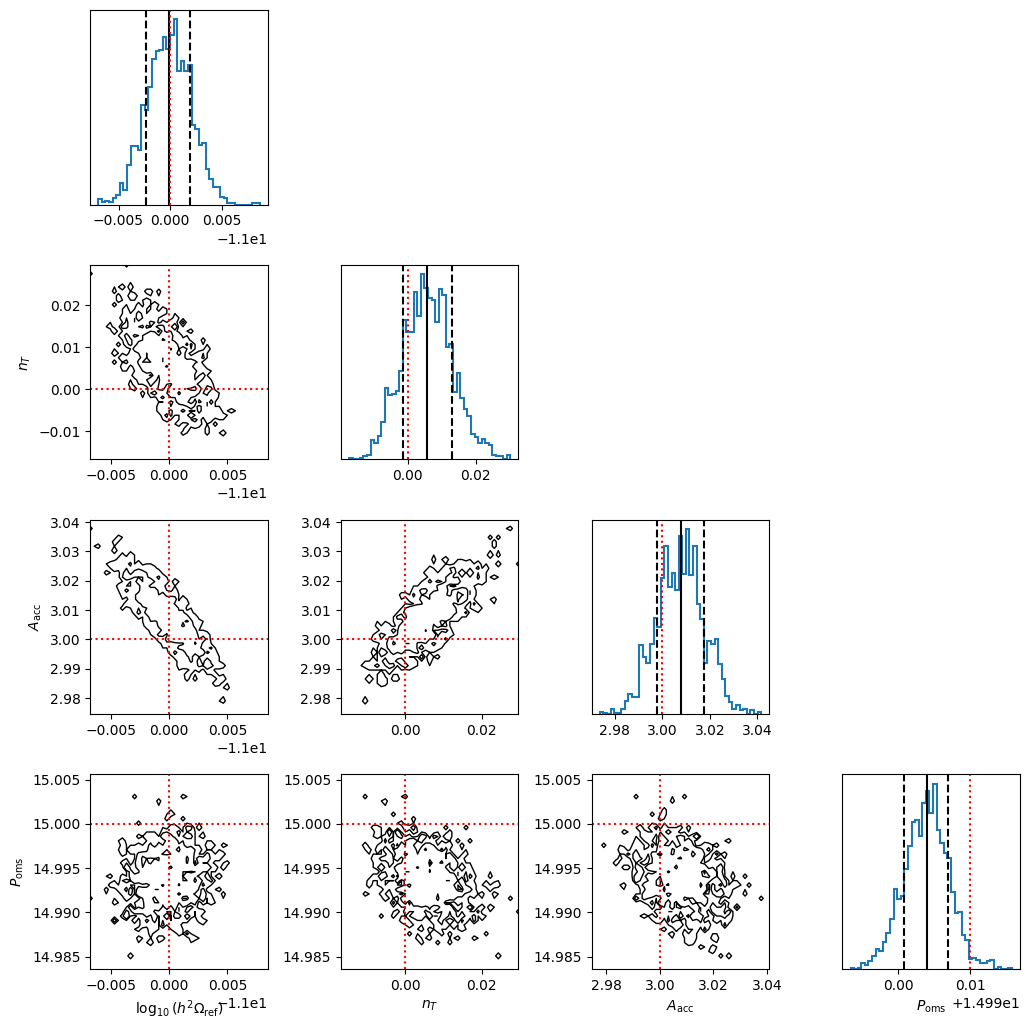

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def metropolis_hastings(logprob_fn, x0, step_cov, n_steps, rng, args=()):
    x = np.array(x0, float)
    dim = x.size
    chain = np.empty((n_steps, dim))
    logp = np.empty(n_steps)

    lp = logprob_fn(x, *args)
    accepts = 0

    for i in range(n_steps):
        x_prop = rng.multivariate_normal(mean=x, cov=step_cov)
        lp_prop = logprob_fn(x_prop, *args)

        if np.isfinite(lp_prop) and (np.log(rng.random()) < (lp_prop - lp)):
            x, lp = x_prop, lp_prop
            accepts += 1

        chain[i] = x
        logp[i] = lp

    return chain, logp, accepts / n_steps

def tune_step_cov(logprob_fn, x0, base_cov, rng, args=(),
                  n_rounds=8, n_steps_per_round=800,
                  target=(0.15, 0.45)):
    """
    Simple multiplicative tuning of the proposal scale.
    Keeps the covariance shape fixed but rescales its overall amplitude.
    """
    scale = 1.0
    cov = np.array(base_cov, float)

    x = np.array(x0, float)
    lp = logprob_fn(x, *args)

    for _ in range(n_rounds):
        cov_try = (scale**2) * cov
        chain, logp, acc = metropolis_hastings(logprob_fn, x, cov_try, n_steps_per_round, rng, args=args)

        x = chain[-1]
        lp = logp[-1]

        if acc < target[0]:
            scale *= 0.5
        elif acc > target[1]:
            scale *= 1.5
        else:
            return cov_try, acc, x

    return (scale**2) * cov, acc, x

def hist2d_contours(ax, x, y, bins=45, levels=(0.68, 0.95)):
    H, xe, ye = np.histogram2d(x, y, bins=bins)
    H = H.T.astype(float)
    H /= np.sum(H)

    Hflat = np.sort(H.ravel())[::-1]
    cdf = np.cumsum(Hflat)

    thr = []
    for lev in levels:
        thr.append(Hflat[np.searchsorted(cdf, lev)])
    thr = sorted(thr)

    xc = 0.5*(xe[:-1] + xe[1:])
    yc = 0.5*(ye[:-1] + ye[1:])
    X, Y = np.meshgrid(xc, yc)
    ax.contour(X, Y, H, levels=thr, colors="k", linewidths=1.0)

def corner_plot(samples, labels, truths=None, bins=45):
    npar = samples.shape[1]
    fig, axes = plt.subplots(npar, npar, figsize=(2.6*npar, 2.6*npar))

    for i in range(npar):
        for j in range(npar):
            ax = axes[i, j]
            if i < j:
                ax.axis("off")
                continue

            if i == j:
                ax.hist(samples[:, i], bins=bins, histtype="step", linewidth=1.5)
                q16, q50, q84 = np.quantile(samples[:, i], [0.16, 0.50, 0.84])
                ax.axvline(q50, color="k")
                ax.axvline(q16, color="k", linestyle="--")
                ax.axvline(q84, color="k", linestyle="--")
                if truths is not None:
                    ax.axvline(truths[i], color="r", linestyle=":")
                ax.set_yticks([])

            else:
                hist2d_contours(ax, samples[:, j], samples[:, i], bins=bins)
                if truths is not None:
                    ax.axvline(truths[j], color="r", linestyle=":")
                    ax.axhline(truths[i], color="r", linestyle=":")

            if i == npar - 1:
                ax.set_xlabel(labels[j])
            if j == 0 and i > 0:
                ax.set_ylabel(labels[i])

    plt.tight_layout()
    return fig

# ----------------------------
# Example END-TO-END run (synthetic data), producing a Fig-11c-style corner plot
# ----------------------------
# Mission/analysis setup (sampling paper defaults)
T_seg = 11.5 * 24.0 * 3600.0
N_c = 95

# Frequency range (you can extend, but keep in mind the response/noise regimes)
edges, f_centers = make_log_frequency_bins(3e-4, 3e-2, n_per_decade=60)

# If you want realistic weights, use n_k_from_edges(...).
# For fast prototyping, you can set n_k = np.ones_like(f_centers).
n_k = n_k_from_edges(edges, T_seg)

# Truth (two signal params + two noise params)
truth = np.array([-11.0, 0.0, 3.0, 15.0])  # [log10(h^2Omega_ref), n_tilt, A_acc, P_oms]

data = simulate_AET_binned_data(
    f_centers, n_k, N_c,
    true_log10_h2Omega_ref=truth[0],
    true_n_tilt=truth[1],
    true_A_acc_fm=truth[2],
    true_P_oms_pm=truth[3],
    seed=123
)

# Posterior function wrapper
rng = np.random.default_rng(0)
logprob = lambda x, d, f, nk, Nc: lnposterior(
    x, d, f, nk, Nc,
    f_ref=3.0e-3,
    response_mode="fit",
    Rtilde_cache=None,
    prior_kwargs=dict(
        mu_A=3.0, mu_P=15.0, frac_sigma=0.2,
        log10Omega_bounds=(-20.0, -6.0),
        nt_bounds=(-5.0, 5.0)
    )
)

# Initial guess
x0 = np.array([-11.2, 0.2, 3.2, 14.8])

# Base proposal covariance (will be tuned)
base_cov = np.diag([0.03, 0.06, 0.04, 0.15])**2

# Tune proposal scale
step_cov, acc_tune, x_start = tune_step_cov(logprob, x0, base_cov, rng, args=(data, f_centers, n_k, N_c))
print("Tuned acceptance (last round):", acc_tune)

# Run MCMC
chain, logp, acc = metropolis_hastings(logprob, x_start, step_cov, n_steps=25000, rng=rng, args=(data, f_centers, n_k, N_c))
print("Acceptance:", acc)

# Burn-in and thinning
burn = 5000
thin = 10
samples = chain[burn::thin]

labels = [
    r"$\log_{10}(h^2\Omega_{\rm ref})$",
    r"$n_T$",
    r"$A_{\rm acc}$",
    r"$P_{\rm oms}$"
]

fig = corner_plot(samples, labels, truths=truth)
plt.show()
